## MSA 2026 Phase 2 - Part 1

In [ ]:
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Consistent look for every plot in the notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

### 1. Find all variables and understand them

#### 1.1 Read the data

In [4]:
# Read the three W store files. 
from pathlib import Path

data_dir = Path("datasets") / "W store sales"
features = pd.read_csv(data_dir / "features.csv")
sales = pd.read_csv(data_dir / "sales.csv")
stores = pd.read_csv(data_dir / "stores.csv")

In [5]:
# Display the first ten instances of each dataset
print(f"Sales Data:\n{sales.head(10)}\n")
print(f"Features Data:\n{features.head(10)}\n")
print(f"Stores Data:\n{stores.head(10)}\n")

Sales Data:
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
5      1     1  2010-03-12      21043.39      False
6      1     1  2010-03-19      22136.64      False
7      1     1  2010-03-26      26229.21      False
8      1     1  2010-04-02      57258.43      False
9      1     1  2010-04-09      42960.91      False

Features Data:
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday
0      1  2010-02-05        42.31       2.572        NaN        NaN        NaN        NaN        NaN  211.096358         8.106      False
1      1  2010-02-12        38.51       2.548        NaN        NaN        NaN        NaN        NaN  211.242170         8.1

The three files are related, not independent:

| File | Grain (one row =) | Role |
|---|---|---|
| `sales.csv` | one store, one department, one week | the **target** (`Weekly_Sales`) |
| `features.csv` | one store, one week | weather / economic / promotional context |
| `stores.csv` | one store | store type and floor size |


In [6]:
# Number of observations (rows) and features (columns) in each table
for name, df in [("sales", sales), ("features", features), ("stores", stores)]:
    print(f"{name:<9} -> {df.shape[0]:>7,} observations, {df.shape[1]:>2} features")

print("\nUnique stores in sales   :", sales["Store"].nunique())
print("Unique departments       :", sales["Dept"].nunique())
print("Store-department series  :", sales.groupby(["Store", "Dept"]).ngroups)
print("Weeks covered (sales)    :", sales["Date"].min(), "->", sales["Date"].max())
print("Weeks covered (features) :", features["Date"].min(), "->", features["Date"].max())

sales     -> 421,570 observations,  5 features
features  ->   8,190 observations, 12 features
stores    ->      45 observations,  3 features

Unique stores in sales   : 45
Unique departments       : 81
Store-department series  : 3331
Weeks covered (sales)    : 2010-02-05 -> 2012-10-26
Weeks covered (features) : 2010-02-05 -> 2013-07-26


**Observations**

The dataset consists of three tables: sales (421,570 records, 5 features), features (8,190 records, 12 features), and stores (45 records, 3 features). The sales data covers 45 stores and 81 departments, forming 3,331 store-department time series. Sales records span from 5 February 2010 to 26 October 2012, while the features dataset extends to 26 July 2013.

### 1.2 Key statistical measures

In [ ]:
# Statistical measures (mean, std, quartiles, ...)
print(f"Sales Data:\n{sales.describe()}\n")
print(f"Features Data:\n{features.describe()}\n")
print(f"Stores Data:\n{stores.describe()}\n")

Sales Data:
               Store           Dept   Weekly_Sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000

Features Data:
             Store  Temperature   Fuel_Price      MarkDown1      MarkDown2      MarkDown3     MarkDown4      MarkDown5          CPI  Unemployment
count  8190.000000  8190.000000  8190.000000    4032.000000    2921.000000    3613.000000   3464.000000    4050.000000  7605.000000   7605.000000
mean     23.000000    59.356198     3.405992    7032.371786    3384.176594    1760.100180   3292.935886    4132.216422   172.460809      7.826821
std      12.987966    18.678607     0.431337    9262.747448    8793.583016 

### 1.3 Data types and missing values

In [7]:
# Check the data type of every column before we change anything
print(f'sales.dtypes: \n{sales.dtypes} \n')
print(f'stores.dtypes: \n{stores.dtypes} \n')
print(f'features.dtypes: \n{features.dtypes} \n')

sales.dtypes: 
Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
dtype: object 

stores.dtypes: 
Store    int64
Type       str
Size     int64
dtype: object 

features.dtypes: 
Store             int64
Date                str
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object 



In [8]:
# Missing values per table (count and percentage)
for name, df in [("sales", sales), ("features", features), ("stores", stores)]:
    miss = df.isna().sum()
    miss = miss[miss > 0]
    print(f"--- {name} ---")
    if miss.empty:
        print("no missing values\n")
    else:
        print(pd.DataFrame({"missing": miss, "pct": (miss / len(df) * 100).round(1)}), "\n")

--- sales ---
no missing values

--- features ---
              missing   pct
MarkDown1        4158  50.8
MarkDown2        5269  64.3
MarkDown3        4577  55.9
MarkDown4        4726  57.7
MarkDown5        4140  50.5
CPI               585   7.1
Unemployment      585   7.1 

--- stores ---
no missing values



### 1.4 Visualise the numerical columns

#### Sales dataset

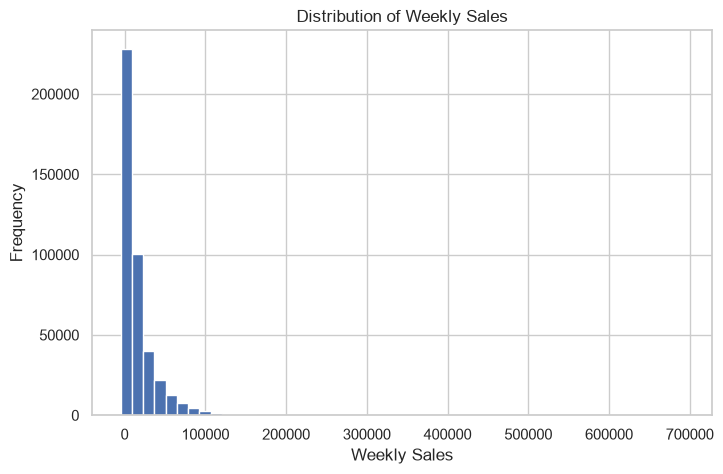

In [9]:
# Distribution of Weekly Sales
plt.figure(figsize=(8, 5))
plt.hist(sales['Weekly_Sales'], bins=50)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

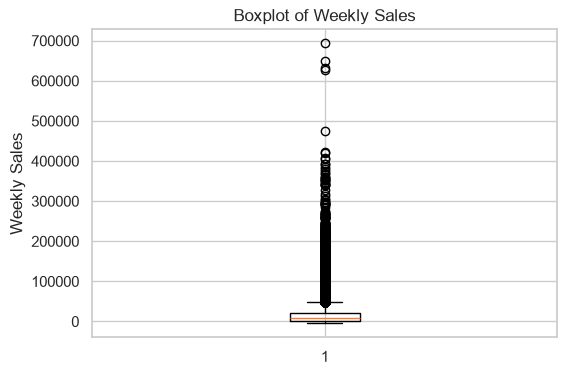

In [10]:
# Boxplot of Weekly Sales
plt.figure(figsize=(6, 4))
plt.boxplot(sales['Weekly_Sales'])
plt.title("Boxplot of Weekly Sales")
plt.ylabel("Weekly Sales")
plt.show()

The histogram shows that weekly sales are **highly right-skewed**. Most observations have relatively low weekly sales, while a small number of observations have very high sales. This indicates that sales are not normally distributed and contain several extreme values.

#### Stores dataset

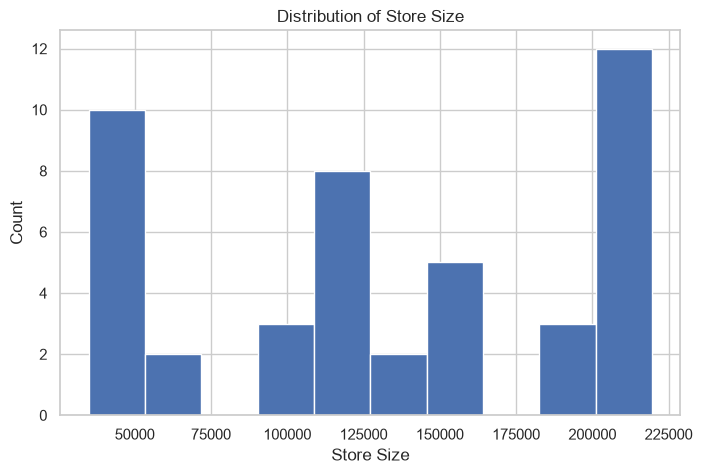

In [11]:
# Distribution of Store Size
plt.figure(figsize=(8, 5))
plt.hist(stores['Size'], bins=10)
plt.title("Distribution of Store Size")
plt.xlabel("Store Size")
plt.ylabel("Count")
plt.show()

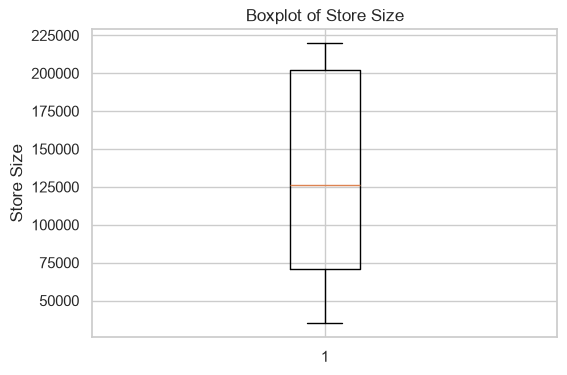

In [12]:
# Boxplot of Store Size
plt.figure(figsize=(6, 4))
plt.boxplot(stores['Size'])
plt.title("Boxplot of Store Size")
plt.ylabel("Store Size")
plt.show()

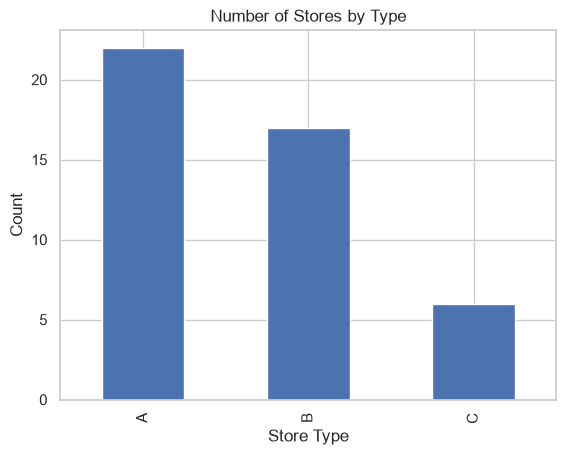

In [13]:
# Distribution of Store Type
stores['Type'].value_counts().plot(kind='bar')
plt.title("Number of Stores by Type")
plt.xlabel("Store Type")
plt.ylabel("Count")
plt.show()

**Distribution of Store Size** : The histogram shows that store sizes vary greatly, ranging from approximately **35,000** to **220,000**. The distribution is not uniform, with many stores concentrated in the larger size range. This suggests that the dataset contains stores of different sizes.

**Boxplot of Store Size** : The boxplot indicates that store sizes are widely distributed, with a median of approximately **125,000**. No obvious outliers are observed, suggesting that store sizes are relatively consistent despite the wide range.

**Distribution of Store Type** : The bar chart shows that **Type A** stores are the most common, followed by **Type B**, while **Type C** stores are the least common. This indicates that the dataset is dominated by Type A stores.

#### Features dataset

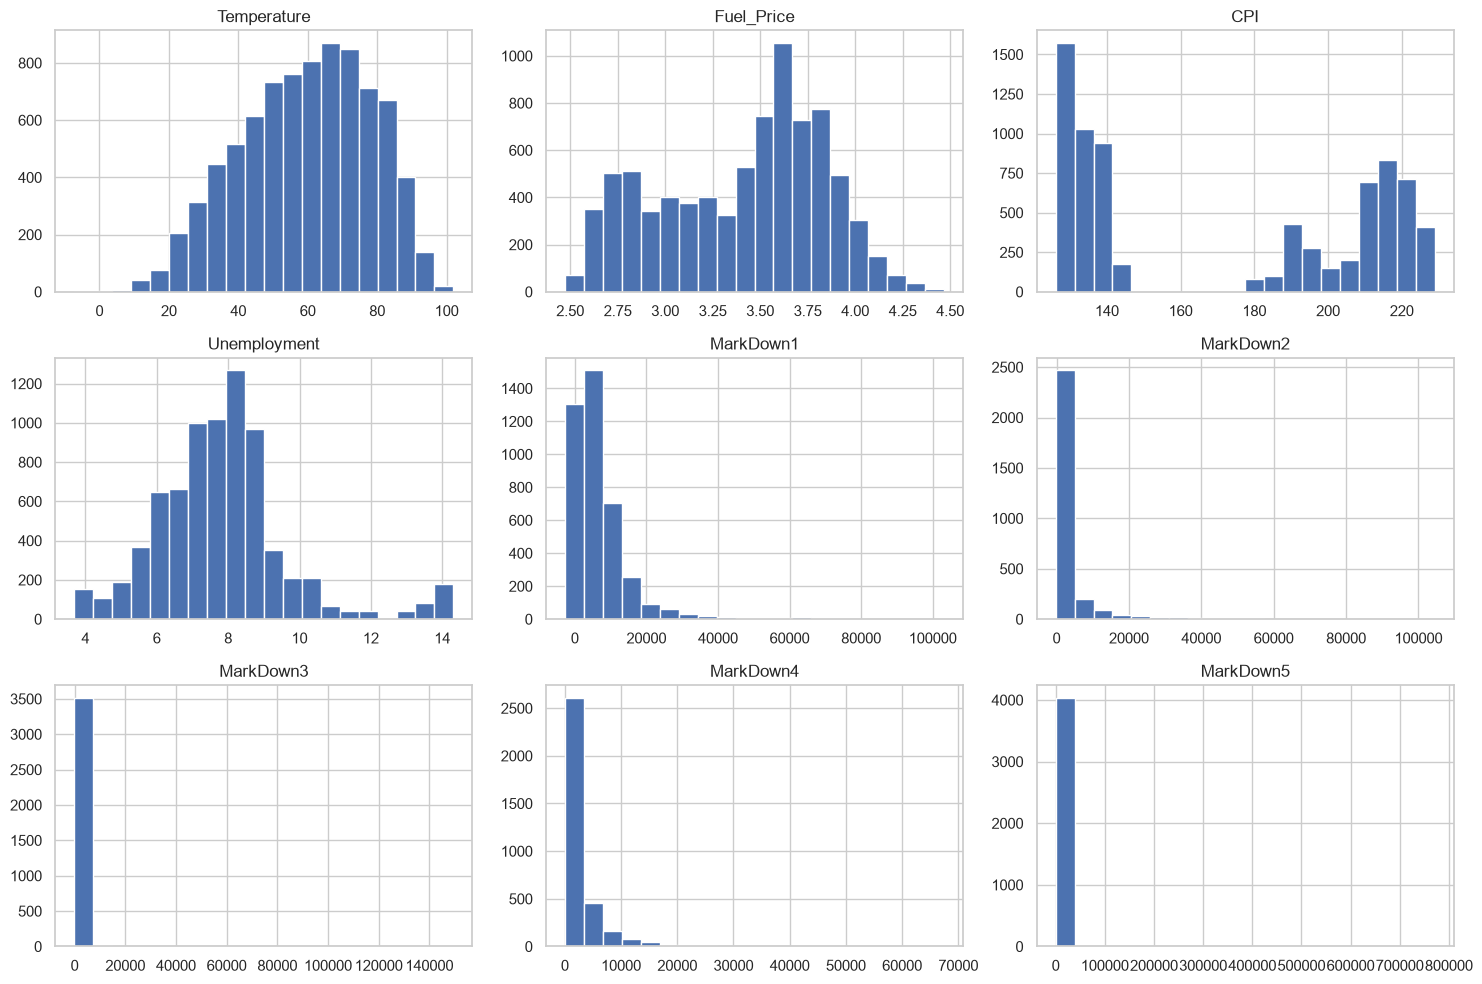

In [14]:
# Distribution of every numeric column in the features table
numerical_cols = [
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

features[numerical_cols].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

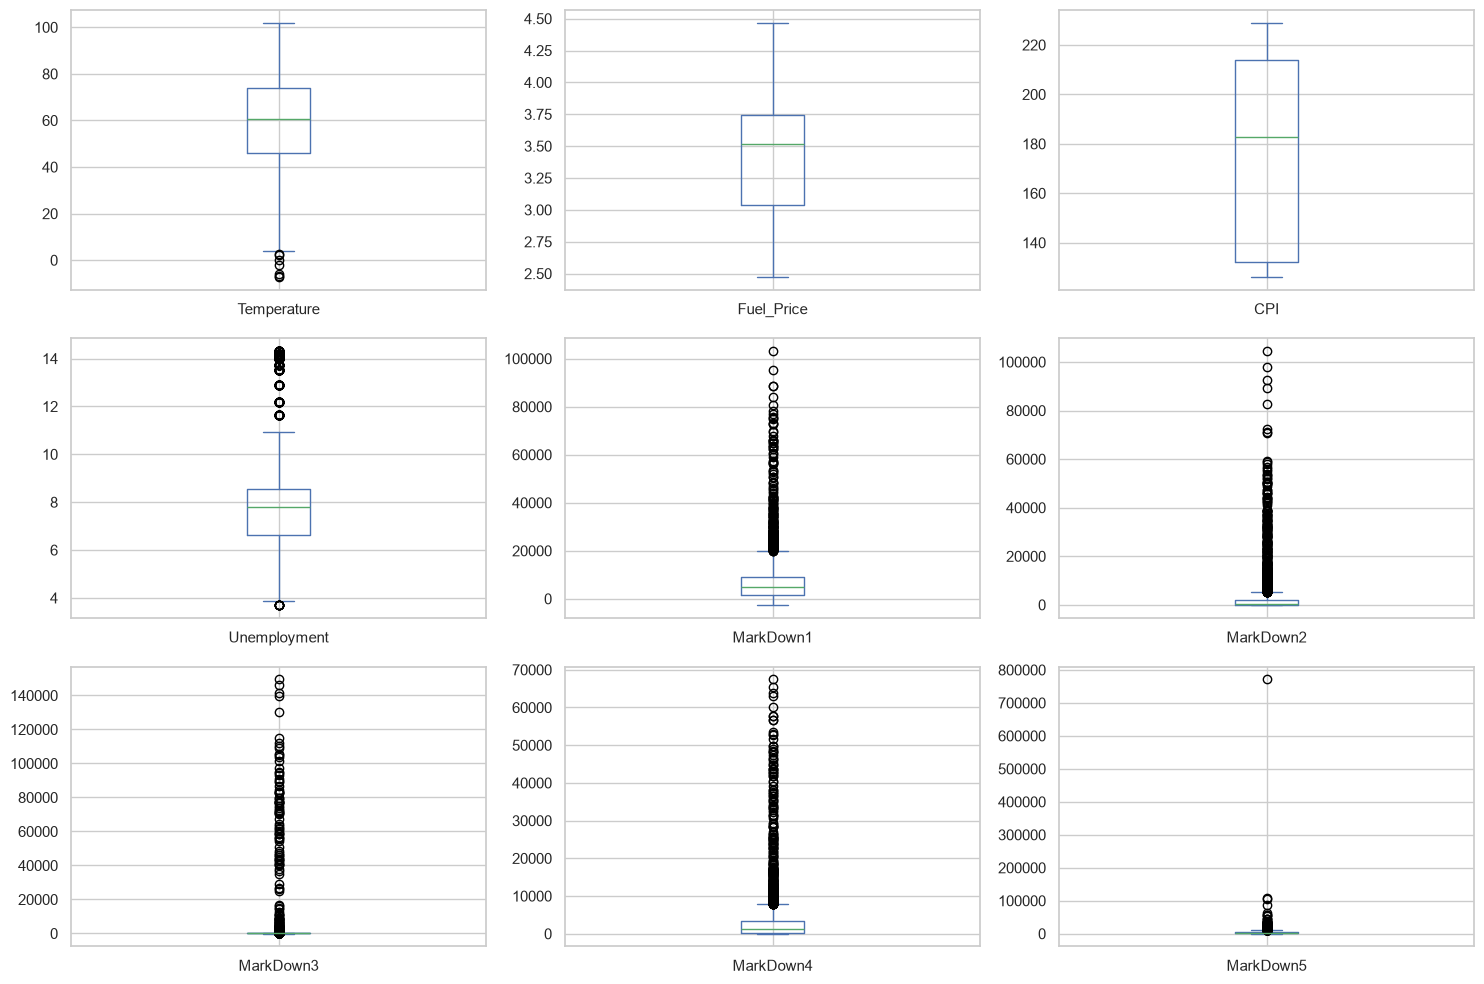

In [15]:
# Boxplot of features data
features[numerical_cols].plot(
    kind='box',
    subplots=True,
    layout=(3, 3),
    figsize=(15, 10)
)
plt.tight_layout()
plt.show()

**Reading these plots**
- Temperature is approximately bell-shaped, with most values between 40 and 80.
- Fuel prices are concentrated between approximately 3.2 and 3.9, with no obvious outliers.
- CPI exhibits a bimodal distribution.
- Unemployment values are mainly between 6 and 9, with several high-value outliers.
- MarkDown1–MarkDown5 are highly right-skewed and contain numerous extreme values.

### 1.5 Convert data types

Machine learning models need numeric input, so we convert:

| Column | From | To | Why |
|---|---|---|---|
| `Date` (sales, features) | `object` | `datetime64` | lets us extract year/month/week and sort chronologically |
| `IsHoliday` (sales, features) | `bool` | `int` | 0/1 is directly usable as a feature |
| `Type` (stores) | `object` (A/B/C) | 3 one-hot `int` columns | nominal categories with no ordering, so one-hot rather than label encoding |

In [7]:
# Convert date columns to datetime type
sales['Date'] = pd.to_datetime(sales['Date'])
features['Date'] = pd.to_datetime(features['Date'])

# Convert boolean columns to integer type (0/1) in BOTH tables that carry the flag
sales['IsHoliday'] = sales['IsHoliday'].astype(int)
features['IsHoliday'] = features['IsHoliday'].astype(int)

# One-hot encode the categorical Store Type column.
# Type is nominal (A/B/C have no natural order), so one-hot avoids implying A < B < C.
stores = pd.get_dummies(
    stores,
    columns=['Type'],
    prefix='Type',
    dtype=int
)

In [8]:
# Confirm every column is now numeric (or a datetime we will expand into numbers later)
print("sales.dtypes:")
print(sales.dtypes)

print("\nstores.dtypes:")
print(stores.dtypes)

print("\nfeatures.dtypes:")
print(features.dtypes)

sales.dtypes:
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                int64
dtype: object

stores.dtypes:
Store     int64
Size      int64
Type_A    int64
Type_B    int64
Type_C    int64
dtype: object

features.dtypes:
Store                    int64
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                int64
dtype: object


## 2. Clean data

Cleaning is done in this order, and every step is justified:

1. **Merge** the three tables into one analysis table
2. **Missing values**
3. **Duplicates and invalid values**
4. **Outliers**
5. **Feature engineering** (calendar features from `Date`)
6. **Imbalance check**
7. **Standardisation / normalisation**
8. **Feature selection**

### 2.1 Merge the three tables

In [11]:
# sales is the table with the target, so we left-join everything onto it.
# features is joined on Store + Date + IsHoliday (IsHoliday is identical in both files,
# so including it in the key avoids creating IsHoliday_x / IsHoliday_y duplicates).
df = (
    sales
    .merge(features, on=["Store", "Date", "IsHoliday"], how="left")
    .merge(stores, on="Store", how="left")
)

print("merged shape:", df.shape)
print("rows preserved from sales:", len(df) == len(sales))
df.head()

merged shape: (421570, 18)
rows preserved from sales: True


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Type_A,Type_B,Type_C
0,1,1,2010-02-05,24924.50,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,151315,1,0,0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,151315,1,0,0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,151315,1,0,0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,151315,1,0,0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,151315,1,0,0


In [12]:
# Which columns still have gaps after the merge?
miss = df.isna().sum()
print(miss[miss > 0] if (miss > 0).any() else "no missing values")

MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64


### 2.2 Handle missing values

In [17]:
first_markdown = df.loc[df["MarkDown1"].notna(), "Date"].min()
first_markdown


Timestamp('2011-11-11 00:00:00')

In [20]:
# The MarkDown columns are the only ones left. When did markdown data start being recorded?
first_markdown = df.loc[df["MarkDown1"].notna(), "Date"].min()
print("first week with markdown data:", first_markdown.date())
print("share of rows before that date :",
      f"{(df['Date'] < first_markdown).mean():.1%}")

first week with markdown data: 2011-11-11
share of rows before that date : 64.1%


**Decision: fill the five `MarkDown` columns with 0 and add a flag column.**

Reasoning: markdown spend was simply not tracked before **2011-11-11**, and even afterwards a blank
means "no promotion ran in that department that week" rather than "value unknown". A markdown of
"nothing" is genuinely **0 dollars**, so 0 is the meaningful fill — imputing the mean would invent
promotions that never happened. Because a 0 from "not recorded" is not quite the same as a 0 from
"no promotion", we keep a `MarkdownRecorded` flag so a model can tell the two regimes apart.

In [18]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

# Flag the rows that come from the period where markdowns were actually tracked
df["MarkdownRecorded"] = (df["Date"] >= first_markdown).astype(int)

# A blank markdown means "no promotion", so 0 is the correct fill value
df[markdown_cols] = df[markdown_cols].fillna(0)

# Small negative markdowns are refunds/corrections; clip to 0 so "promotional spend" stays >= 0
neg = (df[markdown_cols] < 0).sum().sum()
df[markdown_cols] = df[markdown_cols].clip(lower=0)
print(f"negative markdown values clipped to 0: {neg:,}")
print("remaining missing values in the whole table:", int(df.isna().sum().sum()))

negative markdown values clipped to 0: 1,568
remaining missing values in the whole table: 0


### 2.3 Duplicates and invalid values

In [22]:
# Each (Store, Dept, Date) should appear exactly once
dupes = df.duplicated(subset=["Store", "Dept", "Date"]).sum()
print(f"duplicate store-dept-week rows: {dupes:,}")

# Sales cannot logically be negative
negative_sales = df[df["Weekly_Sales"] < 0]
print(f"rows with negative Weekly_Sales : {len(negative_sales):,} ({len(negative_sales)/len(df):.2%})")
print(f"most negative value             : {df['Weekly_Sales'].min():,.2f}")
negative_sales[["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]].head()

duplicate store-dept-week rows: 0


rows with negative Weekly_Sales : 1,285 (0.30%)
most negative value             : -4,988.94


,Store,Dept,Date,Weekly_Sales,IsHoliday
846,1,6,2012-08-10,-139.65,0
2384,1,18,2012-05-04,-1.27,0
6048,1,47,2010-02-19,-863.00,0
6049,1,47,2010-03-12,-698.00,0
6051,1,47,2010-10-08,-58.00,0


**Decision: drop the 1,285 rows with negative `Weekly_Sales` (0.30% of the data).**

Negative Weekly_Sales rows (1,285 records, 0.30% of the dataset) were removed. These values most likely represent returns or accounting adjustments rather than actual customer demand. Since the goal is to build a sales forecasting model, keeping them could bias the model and prevent the use of log transformation. As they account for only a very small proportion of the data, removing them has a negligible impact on the overall dataset.

In [19]:
# Remove the negative sales rows, since they are a small fraction of the data and are likely to be errors.
before = len(df)
df = df[df["Weekly_Sales"] >= 0].copy()
print(f"rows removed : {before - len(df):,}")
print(f"rows remaining: {len(df):,}")

rows removed : 1,285
rows remaining: 420,285


### 2.4 Outliers

In [24]:
# Standard IQR rule applied to the whole target column
q1, q3 = df["Weekly_Sales"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
global_out = df[(df["Weekly_Sales"] < lower) | (df["Weekly_Sales"] > upper)]

print(f"IQR bounds        : {lower:,.0f} to {upper:,.0f}")
print(f"flagged as outlier: {len(global_out):,} rows ({len(global_out)/len(df):.2%})")
print("\nTop departments among the flagged rows:")
print(global_out["Dept"].value_counts().head(5))

IQR bounds        : -25,109 to 47,495
flagged as outlier: 35,381 rows (8.42%)

Top departments among the flagged rows:
Dept
38    4337
95    4233
92    4093
90    2828
40    2792
Name: count, dtype: int64


The standard IQR rule was applied to identify potential outliers in Weekly_Sales. The lower and upper bounds were calculated using 1.5 × IQR, and observations outside this range were flagged. These outliers were further examined by department, as unusually high sales may reflect genuine business events (e.g., holiday demand) rather than data errors.

per-department 3xIQR outliers: 3,832 rows (0.91%)


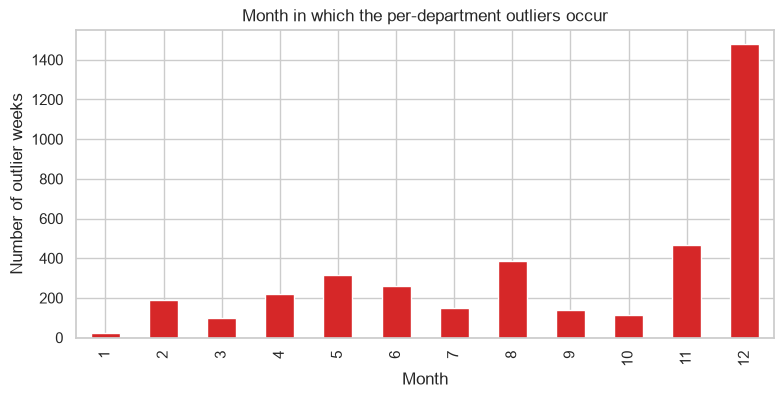

share of outliers in Nov+Dec : 50.8%
holiday-week rate, outliers  : 14.3%
holiday-week rate, all rows  : 7.0%


In [25]:
# Per-department IQR fences (3x IQR), so each department is compared against its own typical range
grp = df.groupby("Dept")["Weekly_Sales"]
q1_d = grp.transform(lambda x: x.quantile(0.25))
q3_d = grp.transform(lambda x: x.quantile(0.75))
iqr_d = q3_d - q1_d

is_outlier = (df["Weekly_Sales"] < q1_d - 3 * iqr_d) | (df["Weekly_Sales"] > q3_d + 3 * iqr_d)
print(f"per-department 3xIQR outliers: {is_outlier.sum():,} rows ({is_outlier.mean():.2%})")

# When do these extreme weeks happen?
month_dist = df.loc[is_outlier, "Date"].dt.month.value_counts().sort_index()
plt.figure(figsize=(9, 4))
month_dist.plot(kind="bar", color="tab:red")
plt.title("Month in which the per-department outliers occur")
plt.xlabel("Month")
plt.ylabel("Number of outlier weeks")
plt.show()

print(f"share of outliers in Nov+Dec : {month_dist.loc[[11, 12]].sum() / month_dist.sum():.1%}")
print(f"holiday-week rate, outliers  : {df.loc[is_outlier, 'IsHoliday'].mean():.1%}")
print(f"holiday-week rate, all rows  : {df['IsHoliday'].mean():.1%}")

**Decision: keep the extreme values, and apply log transform.**

Extreme sales values were retained because they mainly occur during November, December, and holiday weeks, reflecting genuine seasonal demand rather than data errors. Instead of removing these commercially important observations, a log1p transformation was applied to reduce the influence of extreme values, decrease skewness, and improve model performance while allowing predictions to be converted back to the original sales scale using expm1.

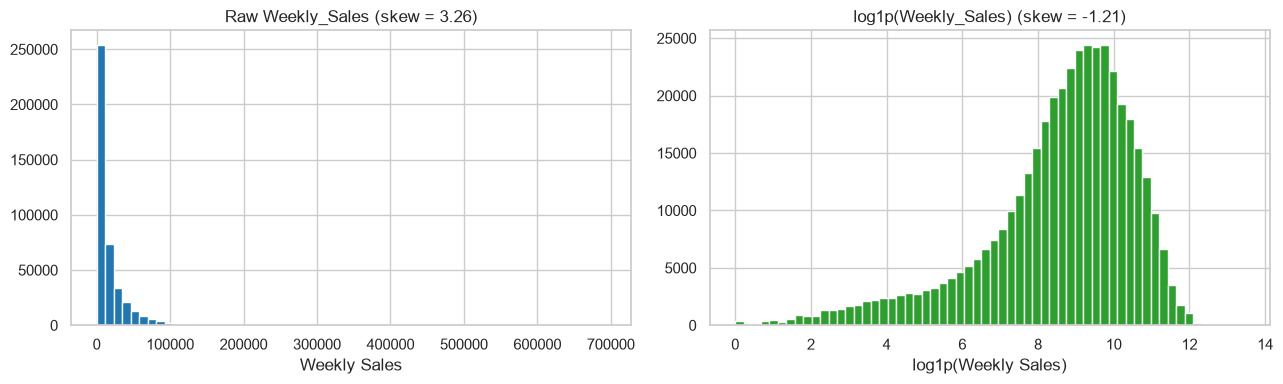

In [26]:
# log1p is safe here because we have already removed negative sales
df["Weekly_Sales_log"] = np.log1p(df["Weekly_Sales"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["Weekly_Sales"], bins=60, color="tab:blue")
axes[0].set_title(f"Raw Weekly_Sales (skew = {df['Weekly_Sales'].skew():.2f})")
axes[0].set_xlabel("Weekly Sales")
axes[1].hist(df["Weekly_Sales_log"], bins=60, color="tab:green")
axes[1].set_title(f"log1p(Weekly_Sales) (skew = {df['Weekly_Sales_log'].skew():.2f})")
axes[1].set_xlabel("log1p(Weekly Sales)")
plt.tight_layout()
plt.show()

### 2.5 Feature engineering — calendar features

In [27]:
# A datetime cannot be fed to a model directly, so expand it into numeric calendar parts.
# Weekly retail sales are strongly seasonal, so these carry real signal.
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["WeekOfYear_sin"] = np.sin(2 * np.pi * df["Week"] / 52)   # cyclical encoding so week 52
df["WeekOfYear_cos"] = np.cos(2 * np.pi * df["Week"] / 52)   # sits next to week 1

df[["Date", "Year", "Month", "Week", "WeekOfYear_sin", "WeekOfYear_cos"]].head()

,Date,Year,Month,Week,WeekOfYear_sin,WeekOfYear_cos
0,2010-02-05,2010,2,5,0.568065,0.822984
1,2010-02-12,2010,2,6,0.663123,0.748511
2,2010-02-19,2010,2,7,0.748511,0.663123
3,2010-02-26,2010,2,8,0.822984,0.568065
4,2010-03-05,2010,3,9,0.885456,0.464723


### 2.6 Imbalance check

In [28]:
# The task is regression, so there is no class label to balance - but IsHoliday is a heavily
# skewed binary feature and it is worth quantifying before relying on it.
counts = df["IsHoliday"].value_counts().sort_index()
print(counts, "\n")
print(f"holiday weeks: {df['IsHoliday'].mean():.2%} of rows")
print("\nmean Weekly_Sales by holiday flag:")
print(df.groupby("IsHoliday")["Weekly_Sales"].agg(["mean", "median", "count"]).round(2))

IsHoliday
0    390722
1     29563
Name: count, dtype: int64 

holiday weeks: 7.03% of rows

mean Weekly_Sales by holiday flag:
               mean   median   count
IsHoliday                           
0          15949.96  7636.08  390722
1          17092.57  7997.86   29563


### 2.7 Standardisation

In [29]:
from sklearn.preprocessing import StandardScaler

# Continuous features live on wildly different scales (Size in the 10^5, Fuel_Price around 3).
# Standardising puts them all on mean 0 / std 1 so distance- and gradient-based models are not
# dominated by whichever column happens to have the biggest units.
scale_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "Size"] + markdown_cols

print("BEFORE scaling:")
print(df[scale_cols].describe().loc[["mean", "std"]].round(2))

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

print("\nAFTER scaling:")
print(df_scaled[scale_cols].describe().loc[["mean", "std"]].round(2))

BEFORE scaling:


      Temperature  Fuel_Price     CPI  Unemployment       Size  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5
mean        60.09        3.36  171.21          7.96  136749.57    2590.19     878.90     468.78    1083.46    1662.71
std         18.45        0.46   39.16          1.86   60992.69    6053.23    5076.51    5533.59    3895.80    4205.95



AFTER scaling:


      Temperature  Fuel_Price  CPI  Unemployment  Size  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5
mean         -0.0         0.0  0.0           0.0  -0.0       -0.0        0.0        0.0       -0.0       -0.0
std           1.0         1.0  1.0           1.0   1.0        1.0        1.0        1.0        1.0        1.0


## 3. Visualise data

Now that the data is merged, cleaned and fully numeric, we visualise the **converted** columns to
look for trends, patterns and anomalies. The focus is on the columns that were *not* numeric in
section 1 — the parsed `Date`, the integer `IsHoliday`, and the one-hot `Type` — since the
originally numeric columns were already plotted above.

### 3.1 The converted `Date` column — weekly sales over time

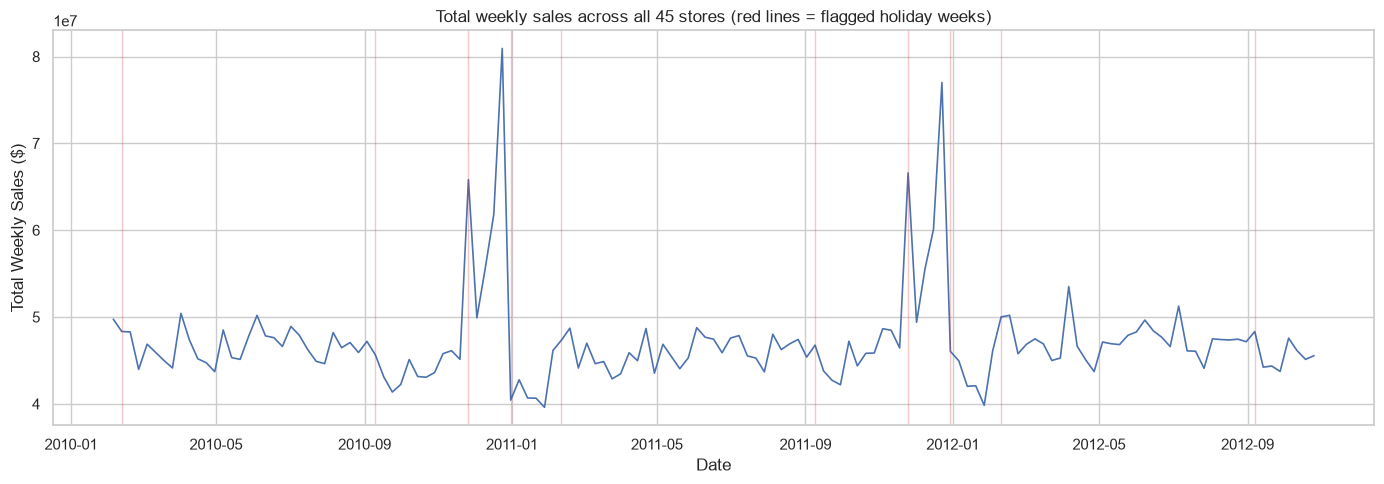

Five highest-selling weeks in the dataset:
Date
2010-12-24    80931586.0
2011-12-23    76999774.0
2011-11-25    66593836.0
2010-11-26    65821216.0
2010-12-17    61821318.0


In [ ]:
# Total sales across all stores/departments for each week
weekly = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly.values, linewidth=1.2)

# Mark the weeks the dataset flags as holidays
holiday_weeks = df.loc[df["IsHoliday"] == 1, "Date"].unique()
for hw in holiday_weeks:
    plt.axvline(hw, color="tab:red", alpha=0.25, linewidth=1)
 
plt.title("Total weekly sales across all 45 stores (red lines = flagged holiday weeks)")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales ($)")
plt.tight_layout()
plt.show()

print("Five highest-selling weeks in the dataset:")
print(weekly.sort_values(ascending=False).head(5).round(0).to_string())

**Trend / pattern / anomaly**

The sales series shows little long-term growth but a clear annual seasonal pattern, with major sales peaks occurring around Thanksgiving and the week before Christmas each year. Interestingly, the highest sales weeks are not always flagged by IsHoliday, indicating that the holiday indicator does not fully capture pre-holiday shopping behaviour.

### 3.2 Monthly seasonality

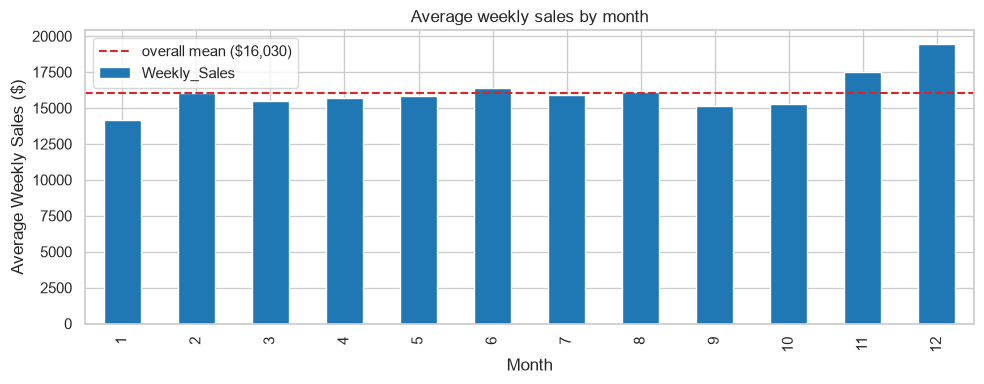

In [31]:
monthly = df.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(10, 4))
monthly.plot(kind="bar", color="tab:blue")
plt.axhline(df["Weekly_Sales"].mean(), color="tab:red", linestyle="--",
            label=f"overall mean (${df['Weekly_Sales'].mean():,.0f})")
plt.title("Average weekly sales by month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

The chart shows a clear seasonal pattern, with December recording the highest average weekly sales and January the lowest, reflecting strong Christmas demand followed by a post-holiday decline. However, the dataset ends in October 2012, meaning the December average is calculated from only two years of data, while January–October averages are based on three years. This difference should be considered when interpreting the monthly averages.

### 3.3 The converted `Type` columns — store type and size

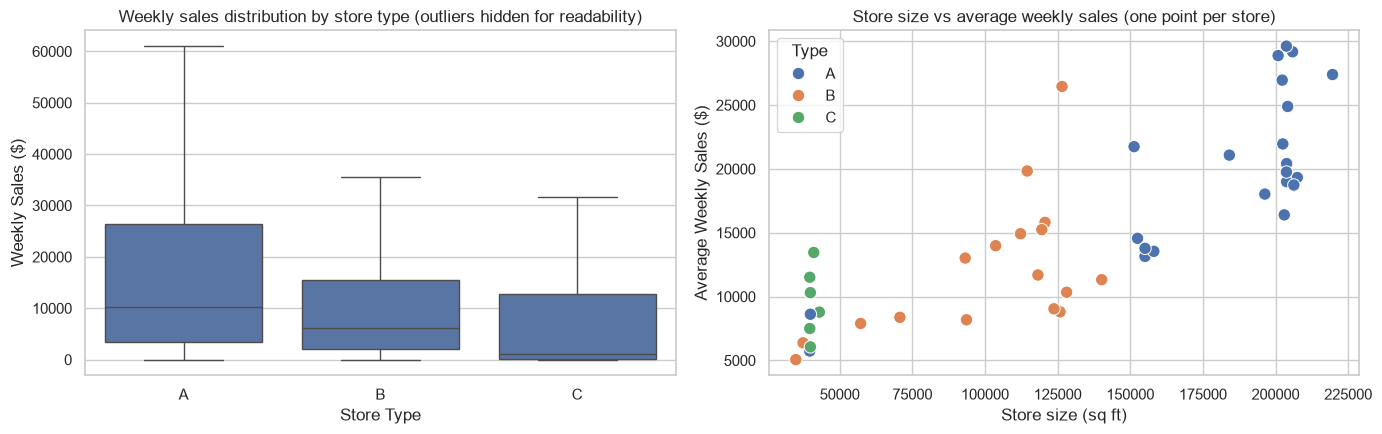

      mean   median   count
A  20145.1  10151.4  214993
B  12288.1   6244.0  162819
C   9547.4   1162.2   42473


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Rebuild a readable label from the one-hot columns so the plot is interpretable
type_label = df[["Type_A", "Type_B", "Type_C"]].idxmax(axis=1).str.replace("Type_", "")

sns.boxplot(x=type_label, y=df["Weekly_Sales"], order=["A", "B", "C"], ax=axes[0], showfliers=False)
axes[0].set_title("Weekly sales distribution by store type (outliers hidden for readability)")
axes[0].set_xlabel("Store Type")
axes[0].set_ylabel("Weekly Sales ($)")

store_summary = df.groupby("Store").agg(Size=("Size", "first"),
                                        MeanSales=("Weekly_Sales", "mean")).reset_index()
store_summary["Type"] = (df.groupby("Store")[["Type_A", "Type_B", "Type_C"]]
                           .first().idxmax(axis=1).str.replace("Type_", "").values)
sns.scatterplot(data=store_summary, x="Size", y="MeanSales", hue="Type",
                hue_order=["A", "B", "C"], s=80, ax=axes[1])
axes[1].set_title("Store size vs average weekly sales (one point per store)")
axes[1].set_xlabel("Store size (sq ft)")
axes[1].set_ylabel("Average Weekly Sales ($)")

plt.tight_layout()
plt.show()

print(df.groupby(type_label)["Weekly_Sales"].agg(["mean", "median", "count"]).round(1))

Type A stores have much higher average sales than Type C stores because store type largely reflects store size. The scatter plot shows that A stores are generally the largest, C stores the smallest, and B stores fall in between. Since Type and Size contain very similar information, one of them may be removed during feature selection to reduce redundancy and multicollinearity.

### 3.4 The converted `IsHoliday` flag

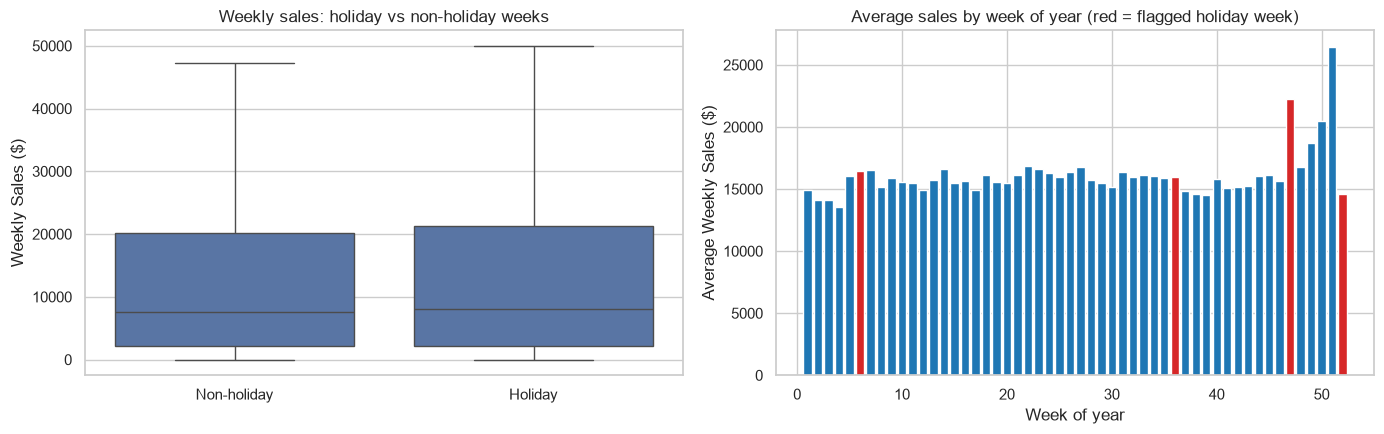

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(x=df["IsHoliday"], y=df["Weekly_Sales"], ax=axes[0], showfliers=False)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Non-holiday", "Holiday"])
axes[0].set_title("Weekly sales: holiday vs non-holiday weeks")
axes[0].set_ylabel("Weekly Sales ($)")
axes[0].set_xlabel("")

# Average sales by week-of-year highlights where the real peaks sit
week_avg = df.groupby("Week")["Weekly_Sales"].mean()
week_holiday = df.groupby("Week")["IsHoliday"].max()
colors = ["tab:red" if week_holiday[w] == 1 else "tab:blue" for w in week_avg.index]
axes[1].bar(week_avg.index, week_avg.values, color=colors)
axes[1].set_title("Average sales by week of year (red = flagged holiday week)")
axes[1].set_xlabel("Week of year")
axes[1].set_ylabel("Average Weekly Sales ($)")

plt.tight_layout()
plt.show()

The boxplot shows only a small difference in sales between holiday and non-holiday weeks. The weekly sales chart explains why: while Black Friday (Week 47) is correctly flagged as a holiday, the highest sales occur in Week 51, the week before Christmas, which is not marked as a holiday. This indicates that IsHoliday captures the holiday date itself rather than the surrounding shopping period, making it a relatively weak predictor of holiday-related sales.

### 3.5 Markdown coverage over time

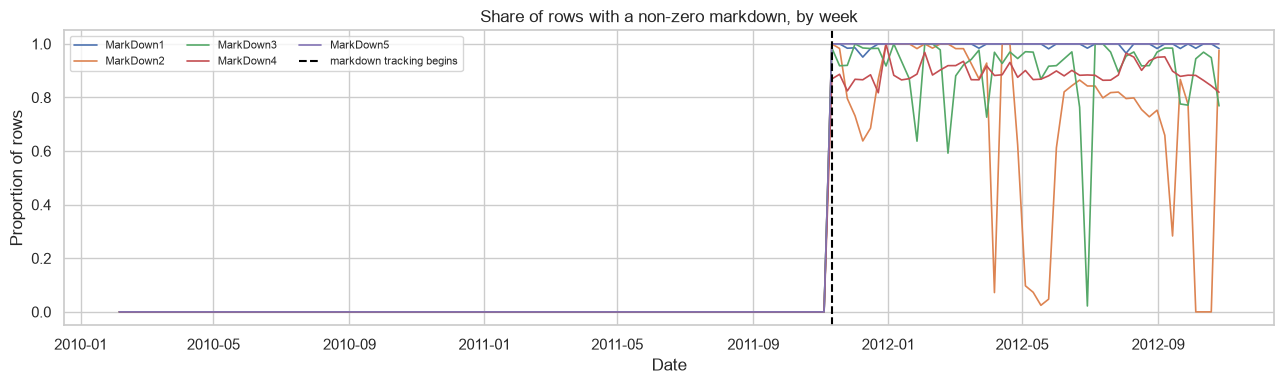

In [34]:
coverage = df.groupby("Date")[markdown_cols].apply(lambda x: (x > 0).mean())

plt.figure(figsize=(13, 4))
for c in markdown_cols:
    plt.plot(coverage.index, coverage[c], label=c, linewidth=1.2)
plt.axvline(first_markdown, color="black", linestyle="--", label="markdown tracking begins")
plt.title("Share of rows with a non-zero markdown, by week")
plt.xlabel("Date")
plt.ylabel("Proportion of rows")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

The plot confirms a clear structural break in the markdown variables. Before 2011-11-11, markdown data is entirely absent, indicating that promotional information was not yet collected. After this date, markdown values appear regularly but vary over time, showing that promotions were recorded only when they occurred. This justifies adding the MarkdownRecorded indicator, allowing the model to distinguish between "no promotion" and "promotion data not available", rather than interpreting all zero values as genuine zero promotional spending.

## 4. Identify correlated variables

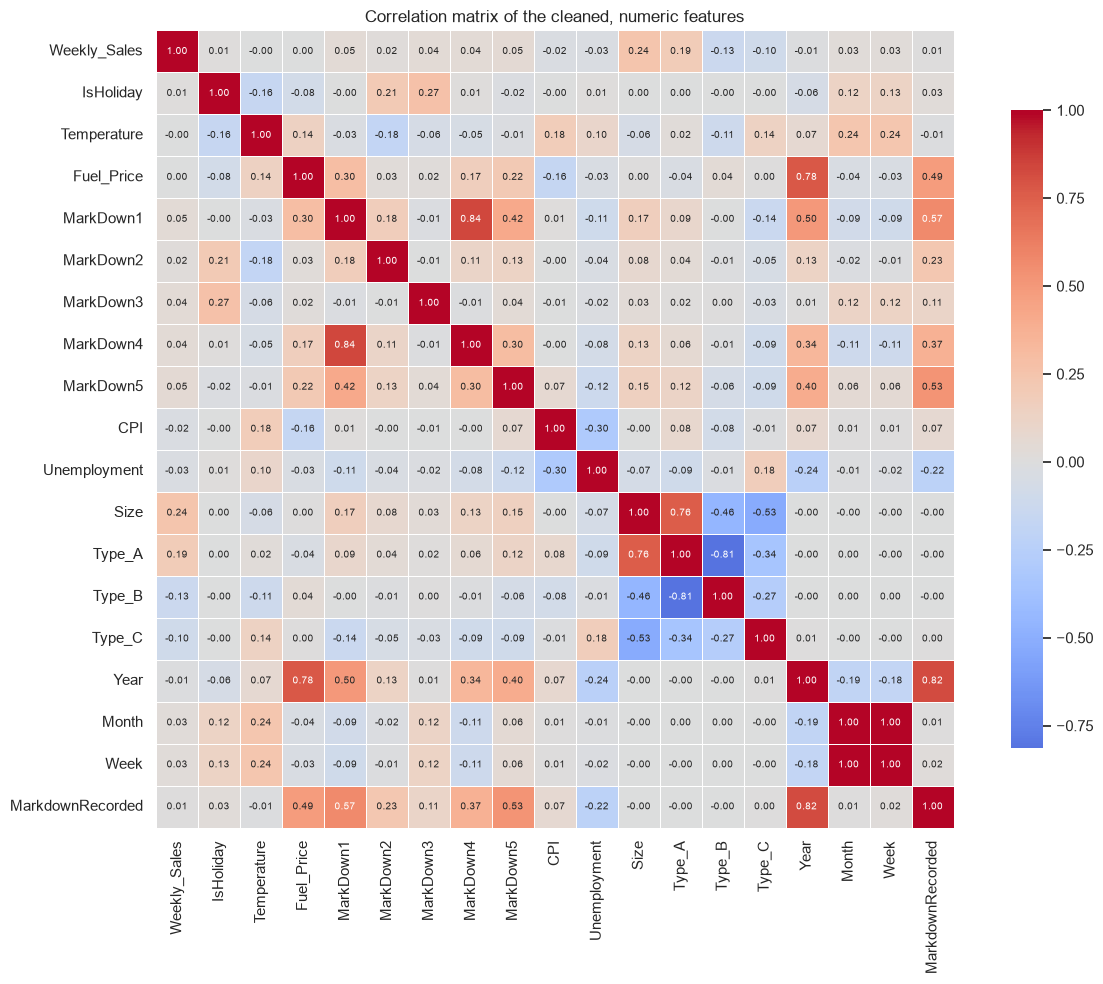

In [35]:
# Build the numeric matrix for correlation. Store and Dept are ID codes, not quantities -
# a "higher" store number means nothing - so they are excluded.
corr_cols = [
    "Weekly_Sales", "IsHoliday", "Temperature", "Fuel_Price",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "CPI", "Unemployment", "Size", "Type_A", "Type_B", "Type_C",
    "Year", "Month", "Week", "MarkdownRecorded",
]
corr = df[corr_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, annot_kws={"size": 7},
            cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix of the cleaned, numeric features")
plt.tight_layout()
plt.show()

### 4.1 How each variable relates to the target

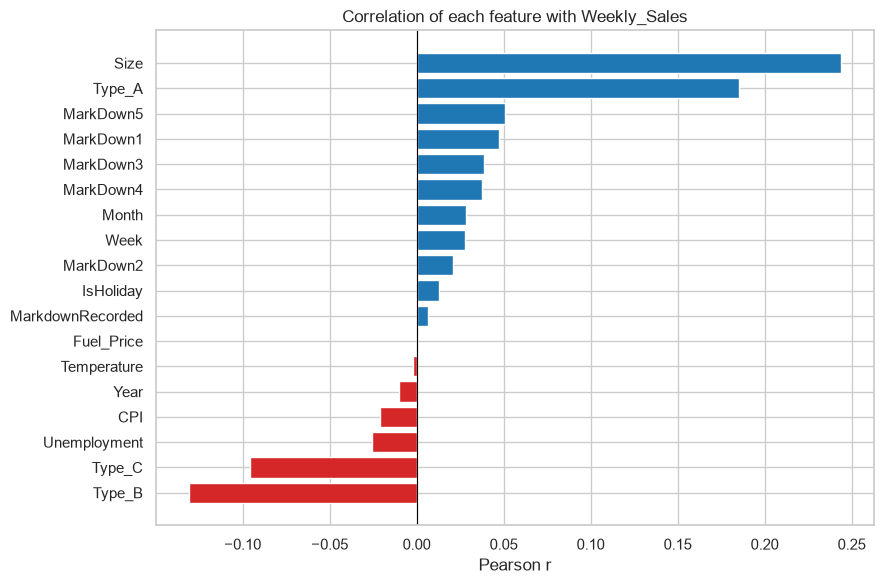

Size                0.244
Type_A              0.185
MarkDown5           0.051
MarkDown1           0.047
MarkDown3           0.039
MarkDown4           0.037
Month               0.028
Week                0.028
MarkDown2           0.021
IsHoliday           0.013
MarkdownRecorded    0.007
Fuel_Price          0.000
Temperature        -0.002
Year               -0.010
CPI                -0.021
Unemployment       -0.026
Type_C             -0.096
Type_B             -0.131


In [36]:
target_corr = corr["Weekly_Sales"].drop("Weekly_Sales").sort_values()

plt.figure(figsize=(9, 6))
colors = ["tab:red" if v < 0 else "tab:blue" for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of each feature with Weekly_Sales")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

print(target_corr.sort_values(ascending=False).round(3).to_string())

**Apparent relationships**

Size has the strongest positive correlation with Weekly_Sales (r = 0.244), indicating that larger stores generally achieve higher sales. Store type shows a similar pattern because it largely reflects store size. Weather and economic variables have correlations close to zero, suggesting little linear relationship with weekly sales. Overall, no single feature strongly explains sales on its own, implying that interactions between variables (such as department and week of the year) and seasonal effects are more important. Therefore, tree-based models are likely to perform better than simple linear models.

### 4.2 Variables that depend on each other

In [37]:
# Find strongly related feature pairs (excluding the target) - these cause multicollinearity
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = (corr.abs()
             .where(mask)
             .stack()
             .sort_values(ascending=False))
pairs = pairs[[i for i in pairs.index if "Weekly_Sales" not in i]]

print("Feature pairs with |r| > 0.7:\n")
for (a, b), v in pairs[pairs > 0.7].items():
    print(f"  {a:<18} <-> {b:<18} r = {corr.loc[a, b]:+.3f}")

Feature pairs with |r| > 0.7:

  Month              <-> Week               r = +0.996
  MarkDown1          <-> MarkDown4          r = +0.839
  Year               <-> MarkdownRecorded   r = +0.820
  Type_A             <-> Type_B             r = -0.814
  Fuel_Price         <-> Year               r = +0.780
  Size               <-> Type_A             r = +0.763


**Decisions — what to drop and why**

| Pair | r | Decision | Reasoning |
|---|---|---|---|
| `Month` <-> `Week` | +0.996 | **drop `Month`** | They measure the same thing; `Week` is finer-grained and matches the weekly grain of the data. Keeping both adds a redundant column and inflates coefficient variance. |
| `MarkDown1` <-> `MarkDown4` | +0.839 | **drop `MarkDown4`** | The two promotions are run together, so `MarkDown4` adds almost no independent information. |
| `Type_A` <-> `Type_B` | -0.814 | **drop `Type_C`** | With three one-hot columns any one is fully determined by the other two (the *dummy variable trap*). Dropping `Type_C` — the smallest group, 6 stores — makes it the reference category and removes the perfect linear dependence. |
| `Size` <-> `Type_A` | +0.763 | **keep both** | Related but not interchangeable: `Size` is continuous and the stronger predictor, while `Type` still separates stores of similar size (see the scatter in 3.3). r = 0.76 is below the ~0.9 threshold where multicollinearity becomes damaging, and tree models are unaffected by it. |
| `Year` <-> `MarkdownRecorded` | +0.820 | **drop `Year`** | Both are proxies for "how far through the dataset we are" — markdown tracking began in late 2011, so the flag is almost a restatement of the year. `MarkdownRecorded` is the one worth keeping because it explains a real change in the *data*, whereas `Year` only encodes a trend that a forecaster cannot extrapolate to an unseen year (r with sales is just -0.010). |
| `Fuel_Price` <-> `Year` | +0.780 | **drop `Fuel_Price`** | Same story: fuel simply got more expensive over 2010-2012, so `Fuel_Price` is a third proxy for time rather than a driver of sales. It has r = 0.000 with sales, so nothing is lost. |

We also drop `CPI`, `Unemployment` and `Temperature`: all three have `|r| < 0.03` with the target
and none is needed to control for anything else in the table.

Seasonality is therefore carried by `Week` plus its sine/cosine pair. Keeping the raw ordinal
*and* the cyclical encoding is deliberate — a tree can split cleanly on the ordinal, while the
cyclical pair gives a linear model a smooth wrap-around at the year boundary.

In [38]:
drop_cols = ["Month", "MarkDown4", "Type_C", "Year", "Fuel_Price", "CPI", "Unemployment", "Temperature"]

final_features = [c for c in corr_cols if c not in drop_cols and c != "Weekly_Sales"]
final_features += ["WeekOfYear_sin", "WeekOfYear_cos", "Store", "Dept"]

print("Dropped :", drop_cols)
print("\nKept    :", final_features)

Dropped : ['Month', 'MarkDown4', 'Type_C', 'Year', 'Fuel_Price', 'CPI', 'Unemployment', 'Temperature']

Kept    : ['IsHoliday', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown5', 'Size', 'Type_A', 'Type_B', 'Week', 'MarkdownRecorded', 'WeekOfYear_sin', 'WeekOfYear_cos', 'Store', 'Dept']


`Store` and `Dept` are added back at the end. They are **identifiers, not quantities**, so they were
rightly excluded from the correlation matrix — but they are the single most informative thing about
a row, and a tree-based model can use them as categorical splits. They would need one-hot or target
encoding before being used in a linear model.

### 4.3 Cross-check with model-based feature importance

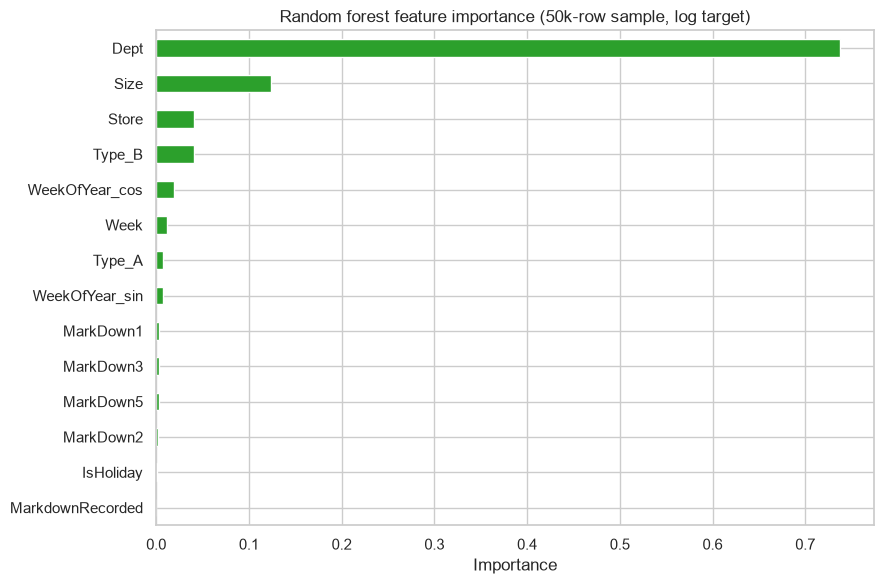

Dept                0.7373
Size                0.1236
Store               0.0407
Type_B              0.0404
WeekOfYear_cos      0.0192
Week                0.0114
Type_A              0.0078
WeekOfYear_sin      0.0071
MarkDown1           0.0034
MarkDown3           0.0032
MarkDown5           0.0031
MarkDown2           0.0021
IsHoliday           0.0005
MarkdownRecorded    0.0003


In [39]:
# Correlation only measures LINEAR association. A random forest picks up non-linear and
# interaction effects, so it is a useful second opinion on which features matter.
from sklearn.ensemble import RandomForestRegressor

sample = df_scaled.sample(n=50_000, random_state=42)
X = sample[final_features]
y = sample["Weekly_Sales_log"]

rf = RandomForestRegressor(n_estimators=60, max_depth=14, random_state=42, n_jobs=-1)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=final_features).sort_values()

plt.figure(figsize=(9, 6))
imp.plot(kind="barh", color="tab:green")
plt.title("Random forest feature importance (50k-row sample, log target)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(imp.sort_values(ascending=False).round(4).to_string())

### 4.4 The final preprocessed dataset

In [40]:
model_df = df_scaled[final_features + ["Weekly_Sales", "Weekly_Sales_log", "Date"]].copy()

print("Final shape:", model_df.shape)
print("Missing values:", int(model_df.isna().sum().sum()))
print("Non-numeric columns (other than Date):",
      [c for c in model_df.columns if c != "Date" and not pd.api.types.is_numeric_dtype(model_df[c])])
print()
model_df.head(10)

Final shape: (420285, 17)
Missing values: 0
Non-numeric columns (other than Date): []



,IsHoliday,MarkDown1,MarkDown2,MarkDown3,MarkDown5,Size,Type_A,Type_B,Week,MarkdownRecorded,WeekOfYear_sin,WeekOfYear_cos,Store,Dept,Weekly_Sales,Weekly_Sales_log,Date
0,0,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,5,0,0.568065,8.229839e-01,1,1,24924.50,10.123647,2010-02-05
1,1,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,6,0,0.663123,7.485107e-01,1,1,46039.49,10.737277,2010-02-12
2,0,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,7,0,0.748511,6.631227e-01,1,1,41595.55,10.635773,2010-02-19
3,0,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,8,0,0.822984,5.680647e-01,1,1,19403.54,9.873262,2010-02-26
4,0,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,9,0,0.885456,4.647232e-01,1,1,21827.90,9.990990,2010-03-05
5,0,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,10,0,0.935016,3.546049e-01,1,1,21043.39,9.954389,2010-03-12
6,0,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,11,0,0.970942,2.393157e-01,1,1,22136.64,10.005035,2010-03-19
7,0,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,12,0,0.992709,1.205367e-01,1,1,26229.21,10.174667,2010-03-26
8,0,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,13,0,1.000000,-1.608123e-16,1,1,57258.43,10.955348,2010-04-02
9,0,-0.427903,-0.173131,-0.084715,-0.395323,0.238806,1,0,14,0,0.992709,-1.205367e-01,1,1,42960.91,10.668069,2010-04-09


## 5. Summary

The W Store Sales dataset contains 421,570 weekly sales records from 45 stores and 81 departments, covering the period from February 2010 to October 2012. The sales, features, and stores datasets were explored separately before being merged into a single dataset for analysis.

The EDA showed that Weekly_Sales is highly right-skewed, with a small number of very high sales weeks and some negative sales values caused by product returns. Sales display clear seasonal patterns, with the highest sales occurring around Black Friday and Christmas. The markdown variables contain a large number of missing values, particularly before late 2011, suggesting that promotional information was not consistently recorded throughout the entire period. Store size varies considerably across stores, and larger stores generally tend to have higher sales.

To prepare the data for modelling, the three datasets were merged using Store and Date. Missing values in the markdown variables were handled, negative sales records were removed, and appropriate data type conversions were applied. The Date column was converted to datetime format, IsHoliday was encoded as a numerical variable, and the categorical Type variable was one-hot encoded. Additional date-related features were created, and redundant variables were removed to reduce multicollinearity. These preprocessing steps produced a clean dataset suitable for model training and evaluation.